In [2]:
import stlrom
from stlrom import Signal, SignalGen, OscillSignalGen, PWCSignalGen
import matplotlib.pyplot as plt
import numpy as np

step_gen = PWCSignalGen()
osc_gen  = OscillSignalGen()


<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

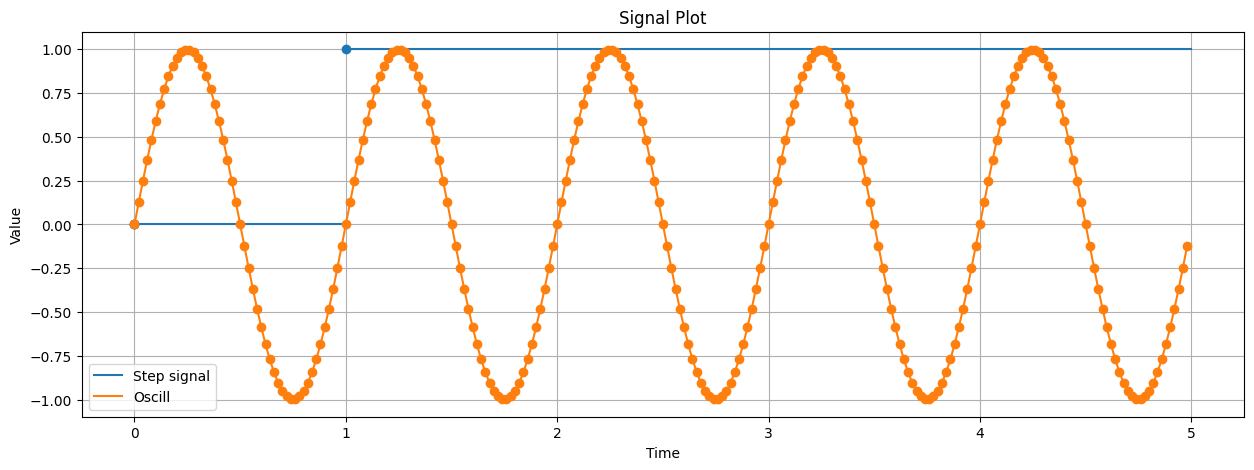

In [3]:
step_sig = step_gen.get_signal(t0=0, tf=5)
ax = step_sig.plot(label= 'Step signal')
sin_sig = osc_gen.get_signal(dt=0.02, tf=5)
sin_sig.plot(ax=ax, label='Oscill')


In [4]:
driver = stlrom.STLDriver()
driver.parse_string('signal step, sin')
driver.parse_string('mu_step := step[t]==0')
driver.parse_string('mu_sin := sin[t]==0')
driver.parse_string('mu_and := mu_step and mu_sin')
driver.parse_string('mu_or := mu_step or mu_sin')
driver.parse_string('phi := mu_and until[0,1] mu_or')

print(driver)

# STLDriver object defined as
signal sin, step

# With formulas
mu_and:= step[t] == 0 and sin[t] == 0
mu_or:= step[t] == 0 or sin[t] == 0
mu_sin:= sin[t] == 0
mu_step:= step[t] == 0
phi:=  (step[t] == 0 and sin[t] == 0) until_[0,1] (step[t] == 0 or sin[t] == 0) 

# Data:
No data yet.


In [5]:
driver.set_signals([step_sig, sin_sig])

print(driver)

# STLDriver object defined as
signal sin, step

# With formulas
mu_and:= step[t] == 0 and sin[t] == 0
mu_or:= step[t] == 0 or sin[t] == 0
mu_sin:= sin[t] == 0
mu_step:= step[t] == 0
phi:=  (step[t] == 0 and sin[t] == 0) until_[0,1] (step[t] == 0 or sin[t] == 0) 

# Data:

# Signal sin:
250 samples from t0=0 to t_end=5

# Signal step:
3 samples from t0=0 to t_end=5



{' (step[t] == 0 and sin[t] == 0) until_[0,1] (step[t] == 0 or sin[t] == 0) ': <stlrom._stlrom.Signal object at 0x728ce29f26b0>, 'sin': <stlrom._stlrom.Signal object at 0x728ce0e37470>, 'sin[t] == 0': <stlrom._stlrom.Signal object at 0x728ce0e35bb0>, 'step': <stlrom._stlrom.Signal object at 0x728ce0e37170>, 'step[t] == 0': <stlrom._stlrom.Signal object at 0x728ce0e10970>, 'step[t] == 0 and sin[t] == 0': <stlrom._stlrom.Signal object at 0x728ce3254670>, 'step[t] == 0 or sin[t] == 0': <stlrom._stlrom.Signal object at 0x728ce3300db0>}
{' (step[t] == 0 and sin[t] == 0) until_[0,1] (step[t] == 0 or sin[t] == 0) ': <stlrom._stlrom.Signal object at 0x728ce2903170>, 'sin': <stlrom._stlrom.Signal object at 0x728ce2901cf0>, 'sin[t] == 0': <stlrom._stlrom.Signal object at 0x728d38223a70>, 'step': <stlrom._stlrom.Signal object at 0x728d38223eb0>, 'step[t] == 0': <stlrom._stlrom.Signal object at 0x728d38223cb0>, 'step[t] == 0 and sin[t] == 0': <stlrom._stlrom.Signal object at 0x728ce3104230>, 'step

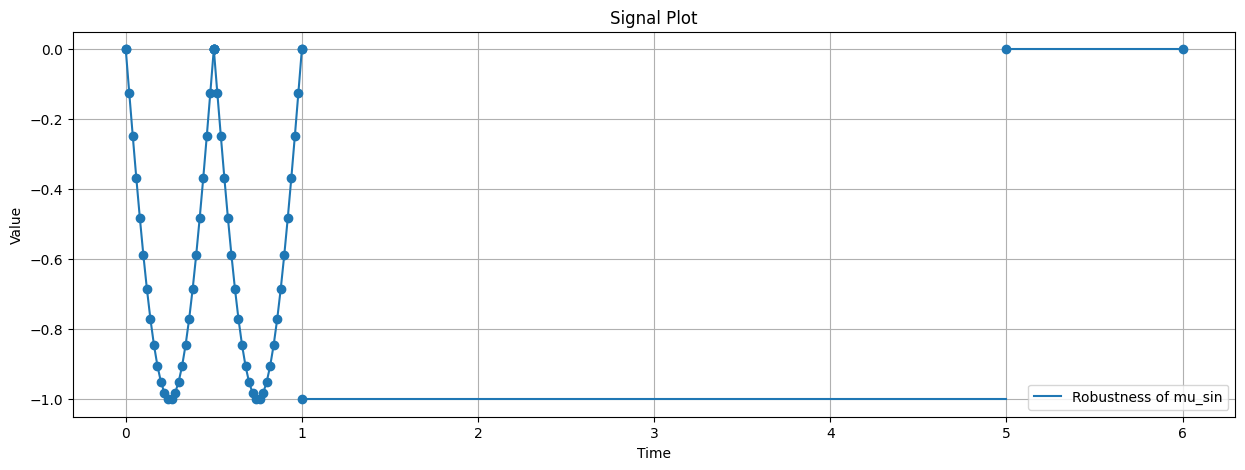

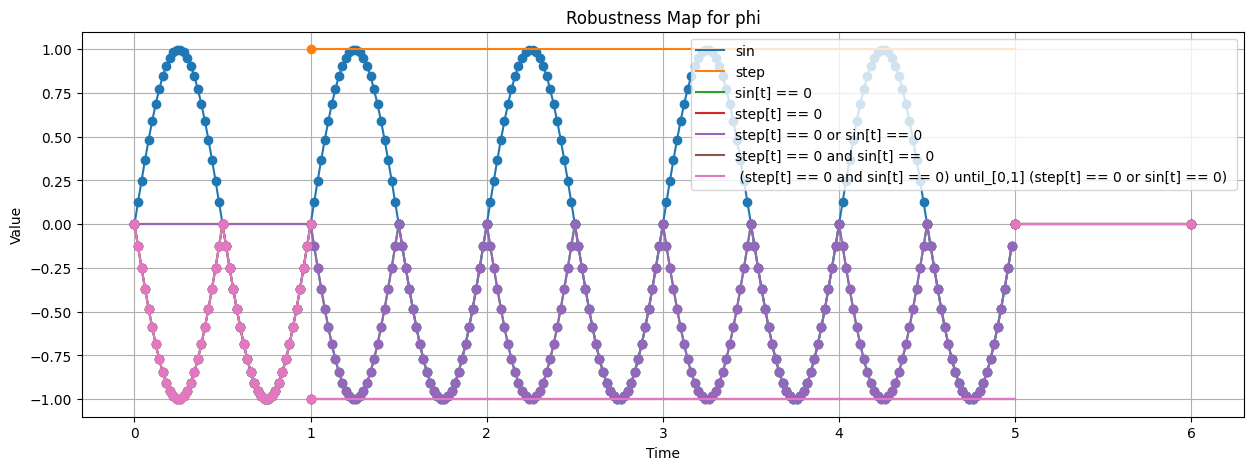

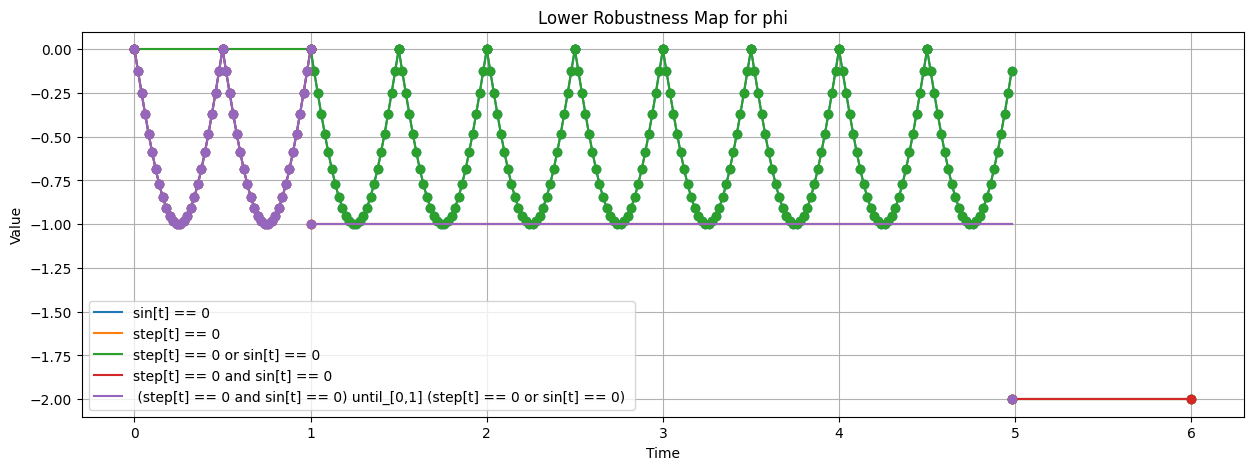

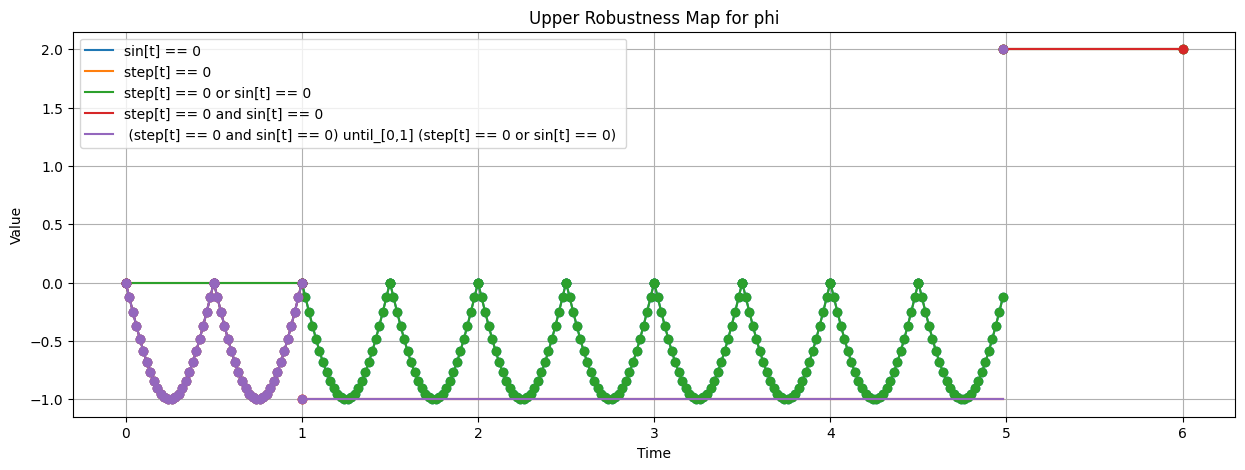

In [6]:
Signal.set_BigM(2)

mon = driver.get_monitor("phi")
rob = mon.eval_online_rob( 0, 5)
ax = rob[0].plot(label='Robustness of mu_sin')
# ax = rob[1].plot(ax=ax, label='Lower bound of robustness of mu_sin')
# ax = rob[2].plot(ax=ax, label='Upper bound of robustness of mu_sin')

monitor_rob_map = mon.get_online_robustness_map()
for rm in monitor_rob_map:
    print(rm)
# print(monitor_rob_map)
from stlrom import plot_rob_map
plot_rob_map(monitor_rob_map[0], same_figure=True, title='Robustness Map for phi')
plot_rob_map(monitor_rob_map[1], same_figure=True, title='Lower Robustness Map for phi')
plot_rob_map(monitor_rob_map[2], same_figure=True, title='Upper Robustness Map for phi')

{' (step[t] == 0 and sin[t] == 0) until_[0,1] (step[t] == 0 or sin[t] == 0) ': <stlrom._stlrom.Signal object at 0x728cda523070>, 'sin': <stlrom._stlrom.Signal object at 0x728cda5202b0>, 'sin[t] == 0': <stlrom._stlrom.Signal object at 0x728ce2910330>, 'step': <stlrom._stlrom.Signal object at 0x728ce29115f0>, 'step[t] == 0': <stlrom._stlrom.Signal object at 0x728ce2913ef0>, 'step[t] == 0 and sin[t] == 0': <stlrom._stlrom.Signal object at 0x728cdabd46f0>, 'step[t] == 0 or sin[t] == 0': <stlrom._stlrom.Signal object at 0x728cdabd70f0>}


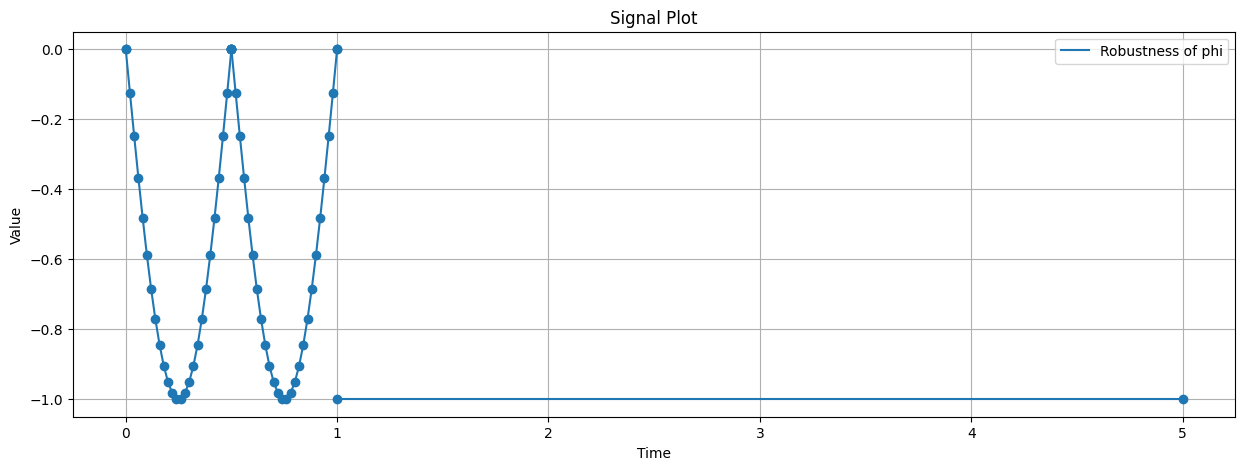

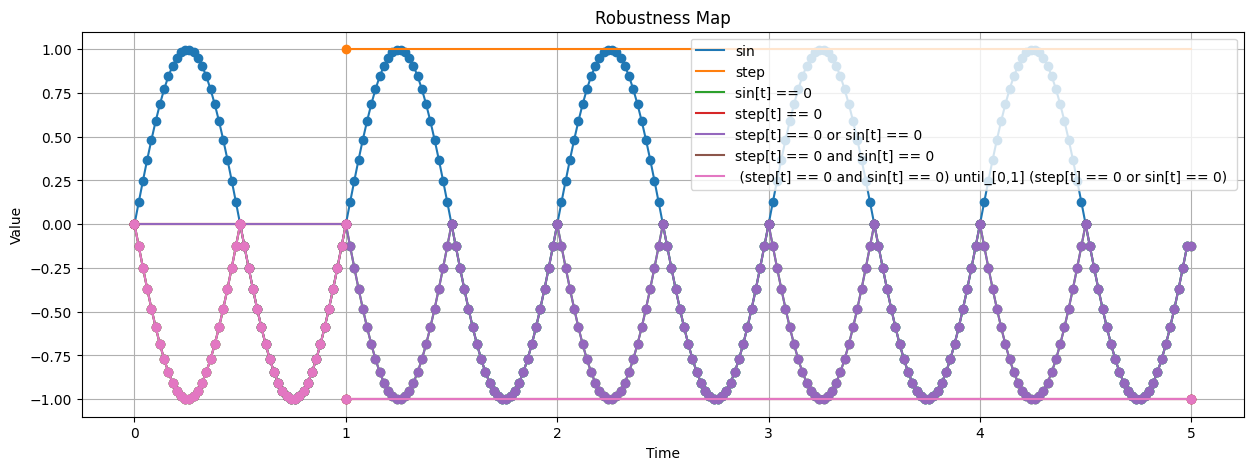

In [7]:
z = driver.eval_rob("phi", 0, 4)
z.plot(label='Robustness of phi')

rob_map = driver.get_robustness_map("phi")
print(rob_map)


# ax = None

# for key in sorted(rob_map, key=len):
#     rob_map[key].plot(label=key, ax=ax)

from stlrom import plot_rob_map
plot_rob_map(rob_map, same_figure=True)

<Axes: title={'center': 'Signal Plot'}, xlabel='Time', ylabel='Value'>

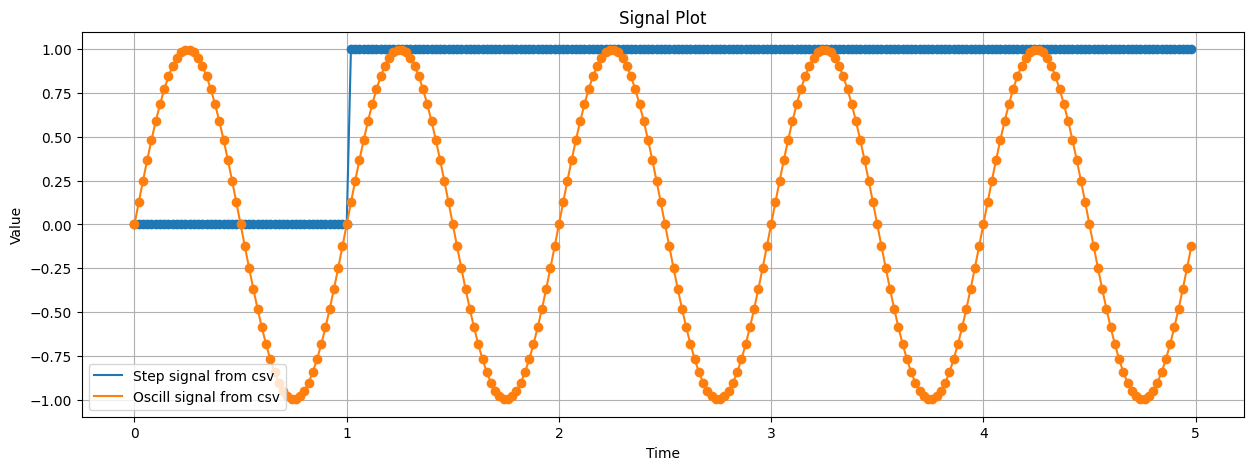

In [8]:
# testing writing and loading csv
driver.write_csv('test_signals.csv')


driver2 = stlrom.STLDriver()
driver2.parse_string('signal step, sin')
driver2.parse_string('mu_step := step[t]==0')
driver2.parse_string('mu_sin := sin[t]==0')
driver2.load_csv('test_signals.csv')

driver2.get_rob('mu_step', 0)

ax2 = driver2.data[0].plot(label='Step signal from csv')
driver2.data[1].plot(ax=ax2, label='Oscill signal from csv')